In [1]:
%matplotlib ipympl

import sys
import numpy as np
from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_to_healpix, reproject_from_healpix
from astropy_healpix import HEALPix
from astropy.table import Table
from astropy.coordinates import SkyCoord, SkyOffsetFrame, Galactic, Angle
import astropy.units as u
import matplotlib.pyplot as plt
from matplotlib import cm, colors
sys.path.append('..')
from mask_utils.coord_utils import  get_pixel_area_map

In [2]:
# --- Configuration ---
#fits_sens_map = "sensitivity_map_mask_050_1040x17_20260129_Crab20260204_Camb_2cameras_max_v2.fits"
fits_sens_map = "sensitivity_map_mask_050_1040x17_20260129_Crab20260204_Camb_2cameras_max_upsx_3_maxf.fits"
#fits_sens_map = "sensitivity_map_mask_050_1040x17_20260129_Crab20260204_Camb_2cameras_max_focal210.fits"
output_filename = "sensitivity_map_mask_combined_healpix_v2_LEMX_10cameras.fits"
nside = 128

In [3]:
# 1. Define Pointing Direction and Roll
center_l, center_b = 0.0, 0.0  # Central target coordinates
instrument_roll = 22.5              # Roll/Rotation in degrees. 23°, together with 60deg angular offset, maximizes the coverage

In [4]:
# 2. Define fixed Camera Offsets (relative to instrument center at 0,0)
# These represent your 5 camera line-of-sights, 30deg elevation 

local_camera_offsets = [
    (0.0, 0.0),   # Camera 1
    (-60, 0.0),  # Camera 2 
    (60, 0.0), # Camera 3
    (0.0, -60) ,  # Camera 4
    (0.0, 60)   # Camera 5   
]




In [5]:
# --- 1. Load the original image data ---
with fits.open(fits_sens_map) as hdul:
    image_header = hdul[0].header
    image_data = hdul[0].data

In [6]:
image_data.shape

(91, 91)

In [7]:
hpx_maps = []

# Create the SkyOffsetFrame centered at your target
center_coord = SkyCoord(l=center_l*u.deg, b=center_b*u.deg, frame='galactic')

# Define the rigid instrument frame
instr_frame = SkyOffsetFrame(origin=center_coord, rotation=Angle(instrument_roll, 'deg'))

for dx, dy in local_camera_offsets:
    # A. Determine the camera center in Galactic coordinates
    cam_coord_instr = SkyCoord(lon=dx*u.deg, lat=dy*u.deg, frame=instr_frame)
    target_pos = cam_coord_instr.transform_to(Galactic())
    
    # B. Calculate the local "Roll Correction"
    # To keep the camera rigid with the instrument, its local WCS rotation 
    # must account for both the global instrument roll and the spherical geometry 
    # shift between the boresight and the camera's off-axis position.
    
    # We find the position angle of the 'Instrument North' at the camera's location
    north_at_cam = SkyCoord(lon=dx*u.deg, lat=(dy+0.0)*u.deg, frame=instr_frame)
    north_at_cam_gal = north_at_cam.transform_to(Galactic())
    
    # The angle between the local Galactic North and the Instrument North
    pa = target_pos.position_angle(north_at_cam_gal)
    
    # C. Set up the WCS
    w = WCS(naxis=2)
    w.wcs.crpix = [46, 46]
    w.wcs.cdelt = [-1.0, 1.0] # Pixel scale
    w.wcs.crval = [target_pos.l.deg, target_pos.b.deg]
    w.wcs.ctype = ["GLON-TAN", "GLAT-TAN"]
    w.pixel_shape = (91, 91)
    # Use the calculated Position Angle to align the pixels rigidly
    theta = pa.radian
    w.wcs.pc = [[np.cos(theta), -np.sin(theta)],
                [np.sin(theta),  np.cos(theta)]]
    
    # D. Reproject
    hpx_array, _ = reproject_to_healpix((image_data, w), 'galactic', nside=nside, nested=False, order='biquadratic')
    hpx_array = np.nan_to_num(hpx_array, nan=1E6)
    hpx_maps.append(hpx_array)

In [8]:
# --- 3. Combine the maps ---
print("Combining maps...")
combined_map = np.nanmin(np.array(hpx_maps), axis=0)
combined_map = np.nan_to_num(combined_map, nan=1E6)

# --- 4. Create and Save the final FITS file ---
# We use a Table for the HEALPix binary table format
t = Table()
t['SENSITIVITY'] = combined_map
t.meta.update({'ORDERING': 'RING', 'COORDSYS': 'G', 'NSIDE': nside})
t.write(output_filename, overwrite=True)

print(f"Successfully saved combined map to {output_filename}")

Combining maps...
Successfully saved combined map to sensitivity_map_mask_combined_healpix_v2_LEMX_10cameras.fits


In [9]:
# --- 3. Reproject to AITOFF for Visualization ---
# Define a target WCS for the AITOFF projection
w_sky = WCS(naxis=2)
w_sky.wcs.ctype = ["GLON-AIT", "GLAT-AIT"]
w_sky.wcs.crval = [0,0]#[center_l, center_b]
w_sky.wcs.crpix = [360, 180] # Center of the output image
w_sky.wcs.cdelt = [-0.5, 0.5] # Resolution: 0.5 deg per pixel
# Optional: define the shape for validity checks
w_sky.pixel_shape = (720, 360)

# Project from HEALPix to the AITOFF image grid
image, footprint = reproject_from_healpix(
    (combined_map, 'galactic'), 
    w_sky, 
    shape_out=(360, 720), 
    nested=False
)

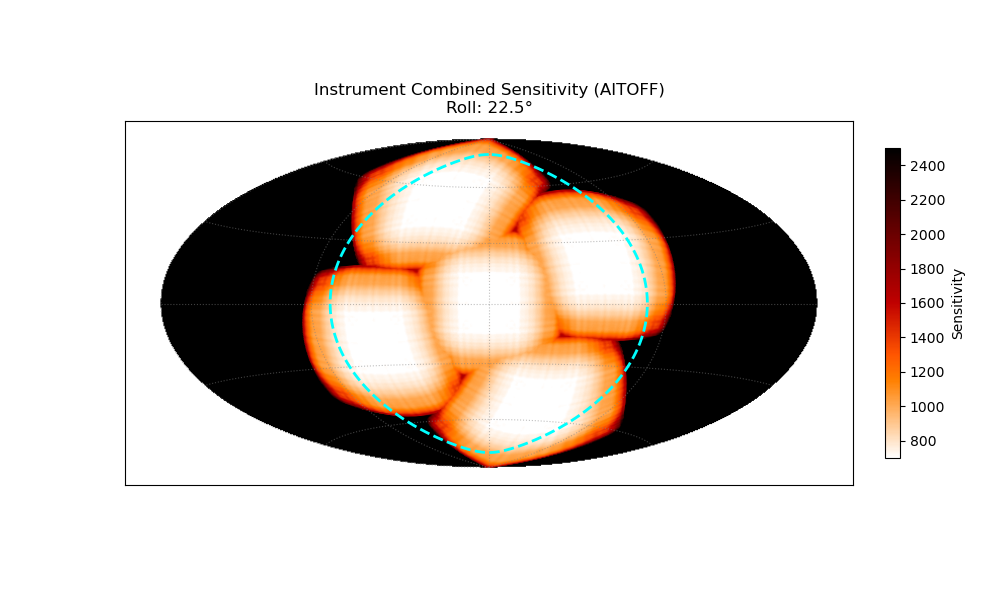

In [24]:
# ==========================================
# NEW CODE: Generate and plot the 80° circle
# ==========================================
# 1. Define the center coordinate
center_coord = SkyCoord(l=center_l*u.deg, b=center_b*u.deg, frame='galactic')

# 2. Generate position angles for the circle (0 to 360 degrees)
angles = np.linspace(0, 360, 500) * u.deg

# 3. Calculate the perimeter coordinates at a constant 80 deg distance
radius = 80 * u.deg
circle_coords = center_coord.directional_offset_by(angles, radius)


# --- 4. Plotting ---
plt.figure(figsize=(10, 6))
ax = plt.subplot(projection=w_sky)
im = ax.imshow(image, origin='lower', cmap=cm.gist_heat_r, vmin=700, vmax=2500)


ax.plot(circle_coords.l.deg, circle_coords.b.deg, 
        transform=ax.get_transform('world'), 
        color='cyan', linewidth=2, linestyle='--', label='80° ROI')

ax.coords.grid(color='gray', linestyle='dotted', alpha=0.5)
ax.coords[0].set_axislabel('Galactic Longitude')
ax.coords[1].set_axislabel('Galactic Latitude')

plt.colorbar(im, label='Sensitivity', fraction=0.02, pad=0.04)
plt.title(f'Instrument Combined Sensitivity (AITOFF)\nRoll: {instrument_roll}°')
plt.show()

In [11]:
def plot_healpix_3d(hpx_map, nside, nested=False, title="3D HEALPix Map"):
    # 1. Setup the HEALPix projection object
    hp = HEALPix(nside=nside, order='nested' if nested else 'ring', frame='galactic')

    # 2. Create a spherical grid (Latitude/Longitude)
    # Increase density for a smoother sphere
    lons = np.linspace(0, 360, 200) * u.deg
    lats = np.linspace(-90, 90, 100) * u.deg
    lon_grid, lat_grid = np.meshgrid(lons, lats)

    # 3. Map the HEALPix data to the grid
    # Find which HEALPix pixel index corresponds to each grid point
    indices = hp.lonlat_to_healpix(lon_grid, lat_grid)
    grid_data = hpx_map[indices]

    # Handle NaNs (common in sensitivity maps) for plotting
    # We replace them with a high value or masked value for the colormap
    masked_data = np.ma.masked_invalid(grid_data)
    
    # 4. Convert Spherical Grid to Cartesian (X, Y, Z) for 3D plotting
    # Note: Using standard physics convention for spherical to cartesian
    phi = lon_grid.to(u.rad).value
    theta = (90 * u.deg - lat_grid).to(u.rad).value # Co-latitude
    
    X = np.sin(theta) * np.cos(phi)
    Y = np.sin(theta) * np.sin(phi)
    Z = np.cos(theta)

    # 5. Create the 3D Plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Create a colormap normalization
    norm = colors.Normalize(vmin=700, vmax=3000)
    face_colors = cm.gist_heat_r(norm(grid_data)) # Using 'viridis_r' for sensitivity

    # Set transparency for NaN areas (optional)
    face_colors[np.isnan(grid_data), 3] = 0 

    # Plot the surface
    surf = ax.plot_surface(X, Y, Z, facecolors=face_colors, 
                           antialiased=False, rstride=1, cstride=1,
                           shade=False)

    # Styling
    ax.set_title(title)
    ax.set_axis_off() # Hide the axes for a cleaner sphere look
    
    # Add a colorbar
    m = cm.ScalarMappable(cmap=cm.viridis_r, norm=norm)
    m.set_array(grid_data)
    plt.colorbar(m, ax=ax, shrink=0.5, aspect=10, label='Sensitivity')

    plt.show()

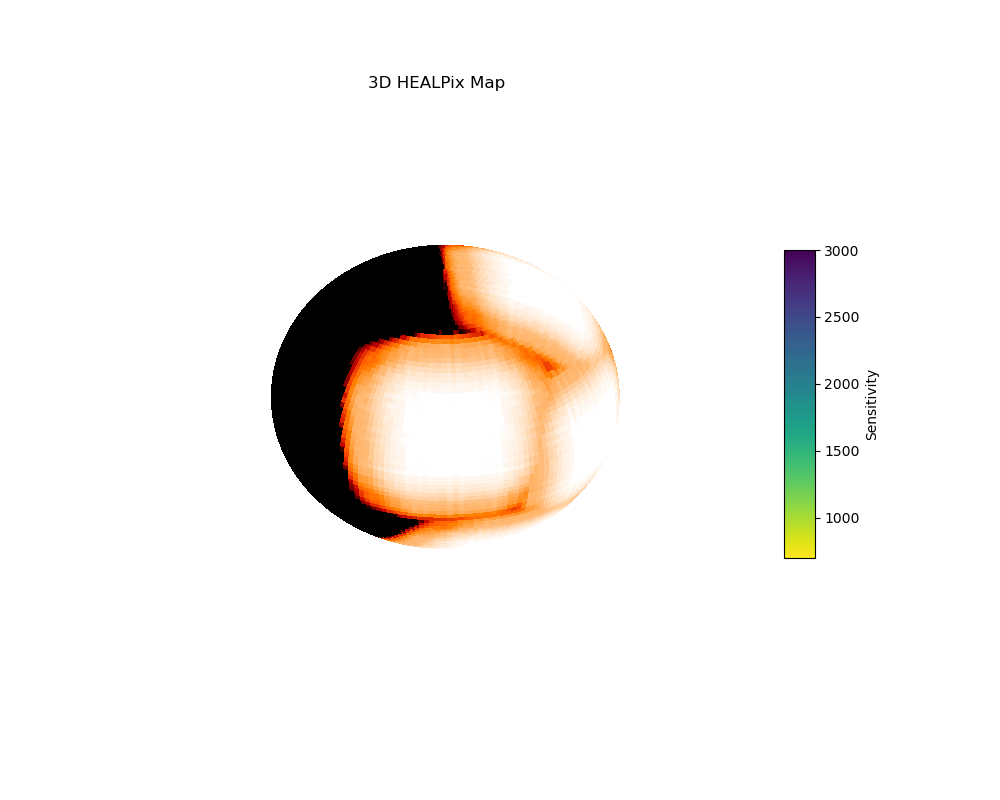

In [12]:
plot_healpix_3d(combined_map, nside=nside, nested=False)

In [13]:
def get_sensitivity_coverage(hpx_map, x_lim):
    """
    Calculates the fraction of the total sphere area where sensitivity is below x_lim.
    """
    # Count pixels where the condition is met
    # Note: np.nan < x_lim will return False
    n_pixels_under_lim = np.count_nonzero( (hpx_map <= x_lim) & (hpx_map >= 500))


    valid_mask = np.isfinite(hpx_map) & (hpx_map <= 1e6)
    n_observed = np.count_nonzero(valid_mask)
    # Total number of pixels in the HEALPix map
    n_total_pixels = len(hpx_map)
    print("Total sky [sr]", 4 * np.pi / (12 * nside**2) * n_observed)
    print("Observed sky [sr]", 4 * np.pi / (12 * nside**2) * n_pixels_under_lim)
    # Fraction of the total sphere
    fraction = n_pixels_under_lim / n_observed
    
    return fraction

In [14]:
x_lim = 1500.0  # Your threshold
area_frac = get_sensitivity_coverage(combined_map, x_lim)

print(f"Coverage for sensitivity < {x_lim}: {area_frac:.2%}")

Total sky [sr] 12.566370614359172
Observed sky [sr] 6.098851949168662
Coverage for sensitivity < 1500.0: 48.53%


In [15]:
def get_sensitivity_coverage_limited(hpx_map, x_lim, center_l, center_b, max_angle_deg, nside=128):
    """
    Calculates the fraction of the observed sphere area where sensitivity is below x_lim,
    restricted to a maximum angular distance from a central coordinate.
    """
    # 1. Initialize the HEALPix object (using 'ring' ordering as defined in your notebook)
    hp = HEALPix(nside=nside, order='ring', frame='galactic')
    
    # 2. Get the Galactic coordinates (l, b) for every pixel in the map
    pixel_indices = np.arange(len(hpx_map))
    lons, lats = hp.healpix_to_lonlat(pixel_indices)
    pixel_coords = SkyCoord(l=lons, b=lats, frame='galactic')
    
    # 3. Define the center coordinate and calculate angular separations
    center_coord = SkyCoord(l=center_l*u.deg, b=center_b*u.deg, frame='galactic')
    separations = center_coord.separation(pixel_coords)
    
    # 4. Create a boolean mask for pixels within the maximum angular distance
    dist_mask = separations <= (max_angle_deg * u.deg)
    
    # 5. Apply the distance mask along with your existing sensitivity conditions
    n_pixels_under_lim = np.count_nonzero((hpx_map <= x_lim) & (hpx_map >= 500) & dist_mask)
    
    # Filter valid/observed pixels that also fall within our angular mask
    valid_mask = np.isfinite(hpx_map) & (hpx_map <= 1e6) & dist_mask
    n_observed = np.count_nonzero(valid_mask)
    
    # Solid angle of a single HEALPix pixel (in steradians)
    pixel_area_sr = 4 * np.pi / (12 * nside**2)
    
    print(f"--- Coverage Stats within {max_angle_deg}° of (l={center_l}, b={center_b}) ---")
    print(f"Total geometric sky in region [sr]: {pixel_area_sr * np.count_nonzero(dist_mask):.4f}")
    print(f"Observed sky in region [sr]:        {pixel_area_sr * n_observed:.4f}")
    print(f"Sky under {x_lim} limit [sr]:          {pixel_area_sr * n_pixels_under_lim:.4f}")
    print(f"Sky fraction under {x_lim} limit [sr]:          { (pixel_area_sr * n_pixels_under_lim)/(4*np.pi):.4f}")
    # Calculate the fraction (safeguard against division by zero)
    fraction = n_pixels_under_lim / n_observed if n_observed > 0 else 0.0
    
    return fraction

In [22]:
x_lim = 1500.0
max_angle = 80.0 # Deg. considering a max FoV obstruction of 10◦ above the horizon, accounting for both the lunar platform and local terrain

area_frac = get_sensitivity_coverage_limited(
    hpx_map=combined_map, 
    x_lim=x_lim, 
    center_l=center_l,  # Uses the variables you defined in Cell 3
    center_b=center_b, 
    max_angle_deg=max_angle,
    nside=nside
)

print(f"\\nCoverage for sensitivity < {x_lim} (within {max_angle}°): {area_frac:.2%}")

--- Coverage Stats within 80.0° of (l=0.0, b=0.0) ---
Total geometric sky in region [sr]: 5.1941
Observed sky in region [sr]:        5.1941
Sky under 1500.0 limit [sr]:          4.9990
Sky fraction under 1500.0 limit [sr]:          0.3978
\nCoverage for sensitivity < 1500.0 (within 80.0°): 96.24%
